<div style="background:linear-gradient(135deg,#0a1230 0%,#141d44 55%,#1b1448 100%);border-radius:18px;padding:36px 32px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#00d4ff;font-weight:700;text-transform:uppercase">Part II · Describing Data &nbsp;|&nbsp; Chapter 10</div>
  <div style="font-size:40px;font-weight:900;line-height:1.1;margin:10px 0 6px">Measures of Position <span style="color:#00d4ff">🐍 Notebook</span></div>
  <div style="font-size:16px;color:#b9c2e0;max-width:720px;line-height:1.6">Five demos on where a single value sits in the crowd: percentiles and percentile rank, quartiles and deciles, the cumulative S-curve, why position is outlier-robust, and why software can disagree on the answer.</div>
  <div style="margin-top:18px;font-size:13px;color:#8892b0">Author: <b style="color:#e8eaf6">John Fisher</b> &nbsp;·&nbsp; Statistics, Data Science and AI: A Visual Handbook &nbsp;·&nbsp; 2026</div>
</div>

### 🎯 What you'll build in this notebook

| # | Demo | Idea it builds |
|---|------|----------------|
| 1 | The round trip | percentile (a value) vs percentile rank (a %) |
| 2 | Quartiles &amp; deciles | quantiles are one idea at different grain |
| 3 | The cumulative S-curve | read position two ways from one ogive |
| 4 | Position is robust | percentiles barely move when an outlier appears |
| 5 | Why answers differ | percentile calculation methods compared |

---

## ⚙️ Setup, imports & the book's plotting style

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(10)

NAVY="#0a1230"; INK="#1a2138"; INK_SOFT="#4a5578"
CYAN="#0891b2"; PURPLE="#7c3aed"; AMBER="#d97706"; GREEN="#059669"; PINK="#db2777"; BLUE="#2563eb"; GRID="#e6e9f2"
plt.rcParams.update({
    "figure.facecolor":"white","axes.facecolor":"white","figure.dpi":110,"font.size":11,
    "axes.edgecolor":GRID,"axes.linewidth":1.2,"axes.grid":True,"grid.color":GRID,"axes.axisbelow":True,
    "axes.spines.top":False,"axes.spines.right":False,"axes.titlesize":15,"axes.titleweight":"bold","axes.titlecolor":INK,
    "axes.labelcolor":INK_SOFT,"axes.labelsize":11.5,"xtick.color":INK_SOFT,"ytick.color":INK_SOFT,"legend.frameon":False,
})
def titlecard(ax,t,sub=None):
    ax.set_title(t, loc="left", pad=18)
    if sub: ax.text(0,1.02,sub,transform=ax.transAxes,fontsize=10.5,color=INK_SOFT,va="bottom")
print("✅ Environment ready.")

✅ Environment ready.


<div style="background:#e0f7fb;border-left:5px solid #0891b2;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#0891b2;letter-spacing:1px">DEMO 1 · THE ROUND TRIP</span>
<div style="font-size:22px;font-weight:800;color:#1a2138;margin-top:4px">🎯 Percentile vs percentile rank</div>
<div style="color:#4a5578;margin-top:6px">A percentile is a value at a position ("the score at the 75th percentile"). A percentile rank is a percentage ("this score beats 90% of people"). They are inverse operations.</div>
</div>

In [2]:
scores = pd.Series([55, 62, 68, 70, 71, 75, 78, 82, 85, 88, 90, 95])

# value -> rank: what percent scored at or below 82?
x = 82
rank = (scores <= x).mean() * 100
print(f"Percentile RANK of {x}: {rank:.0f}%  (about {rank:.0f}% scored at or below {x})")

# rank -> value: what score sits at the 75th percentile?
p75 = np.percentile(scores, 75)
print(f"The 75th PERCENTILE is a score of {p75:.1f}")
print("\nValue -> rank, and rank -> value: the two directions undo each other.")

Percentile RANK of 82: 67%  (about 67% scored at or below 82)
The 75th PERCENTILE is a score of 85.8

Value -> rank, and rank -> value: the two directions undo each other.


<div style="background:#f0e9fe;border-left:5px solid #7c3aed;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#7c3aed;letter-spacing:1px">DEMO 2 · QUARTILES & DECILES</span>
<div style="font-size:22px;font-weight:800;color:#1a2138;margin-top:4px">📏 One idea at different resolutions</div>
<div style="color:#4a5578;margin-top:6px">Quartiles cut the data into 4 parts, deciles into 10, percentiles into 100. They are all quantiles. The median is the 50th percentile = 2nd quartile = 5th decile.</div>
</div>

In [3]:
data = scores
q = np.percentile(data, [25, 50, 75])
print(f"Quartiles  Q1, Q2(median), Q3 : {q.round(1)}")

deciles = np.percentile(data, np.arange(10, 100, 10))
print(f"Deciles (10th..90th)          : {deciles.round(1)}")

print(f"\nThe median {np.percentile(data,50):.1f} = 50th percentile = Q2 = 5th decile (all the same point).")

Quartiles  Q1, Q2(median), Q3 : [69.5 76.5 85.8]
Deciles (10th..90th)          : [62.6 68.4 70.3 72.6 76.5 80.4 84.1 87.4 89.8]

The median 76.5 = 50th percentile = Q2 = 5th decile (all the same point).


<div style="background:#fef3e2;border-left:5px solid #d97706;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#d97706;letter-spacing:1px">DEMO 3 · THE CUMULATIVE S-CURVE</span>
<div style="font-size:22px;font-weight:800;color:#1a2138;margin-top:4px">📈 Read position two ways from one picture</div>
<div style="color:#4a5578;margin-top:6px">Plot the cumulative percentage against value (an "ogive"). Read UP from a value to get its percentile rank; read ACROSS from a percentage to get the percentile.</div>
</div>

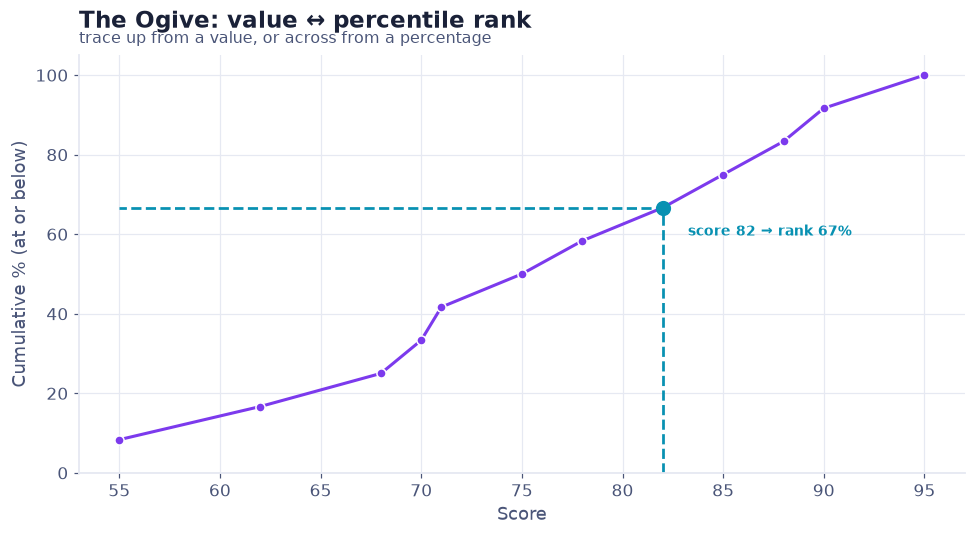

In [4]:
xs = np.sort(scores.values)
cum = np.arange(1, len(xs)+1) / len(xs) * 100   # cumulative percent at or below

fig, ax = plt.subplots(figsize=(9,5))
ax.plot(xs, cum, "-o", color=PURPLE, lw=2, markersize=6, markeredgecolor="white")
# value 82 -> its rank
r = (scores <= 82).mean()*100
ax.plot([82,82,55],[0,r,r], color=CYAN, ls="--", lw=1.8)
ax.scatter([82],[r], color=CYAN, s=80, zorder=5)
ax.text(83, r-7, f" score 82 → rank {r:.0f}%", color=CYAN, fontweight="bold", fontsize=9)
titlecard(ax,"The Ogive: value ↔ percentile rank","trace up from a value, or across from a percentage")
ax.set_xlabel("Score"); ax.set_ylabel("Cumulative % (at or below)"); ax.set_ylim(0,105)
plt.tight_layout(); plt.show()

<div style="background:#e3f6ee;border-left:5px solid #059669;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#059669;letter-spacing:1px">DEMO 4 · POSITION IS ROBUST</span>
<div style="font-size:22px;font-weight:800;color:#1a2138;margin-top:4px">🛡️ Outliers barely move a percentile</div>
<div style="color:#4a5578;margin-top:6px">Because percentiles depend only on rank order, not on how extreme a value is, one wild outlier hardly shifts the median or quartiles, while it wrecks the mean.</div>
</div>

In [5]:
base = pd.Series([20, 22, 24, 25, 27, 29, 31, 33, 35, 40])
withbig = pd.concat([base, pd.Series([5000])], ignore_index=True)

print(f"Original : mean {base.mean():6.1f}, median {base.median():.1f}, Q3 {np.percentile(base,75):.1f}")
print(f"+ outlier: mean {withbig.mean():6.1f}, median {withbig.median():.1f}, Q3 {np.percentile(withbig,75):.1f}")
print("\nThe mean exploded; the median and Q3 barely moved. Position measures are robust.")

Original : mean   28.6, median 28.0, Q3 32.5
+ outlier: mean  480.5, median 29.0, Q3 34.0

The mean exploded; the median and Q3 barely moved. Position measures are robust.


<div style="background:#e6effe;border-left:5px solid #2563eb;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#2563eb;letter-spacing:1px">DEMO 5 · WHY ANSWERS DIFFER</span>
<div style="font-size:22px;font-weight:800;color:#1a2138;margin-top:4px">🔧 There is no single "right" percentile</div>
<div style="color:#4a5578;margin-top:6px">For small samples, percentiles fall between data points, so software interpolates differently. NumPy alone offers many methods. Report which you used.</div>
</div>

In [6]:
sample = np.array([2, 4, 6, 8, 10, 12, 14])
print("First quartile (25th percentile) of", list(sample), "by method:")
for m in ["lower", "higher", "nearest", "midpoint", "linear"]:
    print(f"   method={m:<8} -> {np.percentile(sample, 25, method=m):.2f}")
print("\nAll are legitimate. They differ only because the 25% point sits between two values.")

First quartile (25th percentile) of [np.int64(2), np.int64(4), np.int64(6), np.int64(8), np.int64(10), np.int64(12), np.int64(14)] by method:
   method=lower    -> 4.00
   method=higher   -> 6.00
   method=nearest  -> 6.00
   method=midpoint -> 5.00
   method=linear   -> 5.00

All are legitimate. They differ only because the 25% point sits between two values.


---
<div style="background:#ffffff;border:1px solid #e6e9f2;border-radius:16px;padding:24px 28px;font-family:Inter,sans-serif;box-shadow:0 8px 30px rgba(20,30,80,0.05)">
<div style="font-size:20px;font-weight:800;color:#1a2138">🎓 Recap</div>
<ul style="color:#4a5578;line-height:1.9;margin-top:10px">
<li>A <b>percentile</b> is a value at a position; a <b>percentile rank</b> is the percent at or below a value. Inverse operations.</li>
<li><b>Quartiles, deciles, percentiles</b> are all quantiles: the same idea at different resolutions.</li>
<li>The <b>cumulative S-curve (ogive)</b> shows both directions in one picture.</li>
<li>Position measures are <b>robust</b>: outliers barely move them.</li>
<li>Percentile <b>calculation methods differ</b> on small samples, so report your method.</li>
</ul>
</div>

<div style="text-align:center;color:#8b94b3;font-size:12px;margin-top:18px">Statistics, Data Science and AI: A Visual Handbook · © 2026 John Fisher</div>